# Visualizing Pendulum Dynamics

*By Hongli Zhao*

## Pendulum Dynamics


In [1]:
# numerical libraries
import numpy as np
import scipy as sp
import scipy.integrate
import matplotlib.pyplot as plt # for visualization
%matplotlib inline
from ipywidgets import interactive # interactive visualization

In [2]:
# helper functions
def pendumlum_rhs(t, x):
    """ right hand side of pendulum dynamics for scipy. """
    return np.array([x[1], -np.sin(x[0])])
def energy(theta_sol, omega_sol):
    """ given solutions for (theta, omega) at a certain t, computes energy. """
    return 0.5 * (omega_sol ** 2) - np.cos(theta_sol)
def period(E0, verbose=False):
    """ given a conserved energy level E0, computes the period of pendulum oscillations
    numerically from the integral. """
    lower = 0
    upper = np.arccos(-E0)
    def integrand(theta):
        return 1 / np.sqrt( 2*(E0 + np.cos(theta))) 
    I, abs_err = scipy.integrate.quad(integrand, lower, upper)
    if verbose:
        print("==== Abs. Error from numerical integration: {}".format(abs_err))
    return I
def pendulum_main(theta0, omega0, t_end):
    """ Main driver code for pendulum dynamics numerical solver and plotting. 
    Visualize with varying initial conditions and terminal time. """
    assert theta0 <= np.pi and theta0 >= -np.pi, "theta must be in [-pi, pi]. "
    # initial state
    x0 = np.array([theta0, omega0])
    # time grid with 10000 query points
    t_start, Nt = 0, 10000
    t_span = np.linspace(t_start, t_end, Nt)
    solver = scipy.integrate.solve_ivp(pendumlum_rhs, [t_start, t_end], x0, dense_output=True)
    # generate solution dynamics
    pendulum_solution = np.array(solver.sol(t_span))
    theta_solution = pendulum_solution[0,:]
    omega_solution = pendulum_solution[1,:]
    # restrict theta solution to be withi [-pi, pi]
    theta_solution_res = np.mod(theta_solution + np.pi, 2 * np.pi) - np.pi
    # compute energy
    E_solution = energy(theta_solution, omega_solution)
    fig, axs = plt.subplots(2, 2, figsize=(15,10));
    
    # plot for theta
    axs[0, 0].plot(t_span, theta_solution_res, color="red", lw=2);
    axs[0, 0].set_title(r"Solution for $\theta(t)$ from $t = 0$ to $t = {}$".format(t_end))
    axs[0, 0].set_xlabel(r"Time $t$"); axs[0, 0].set_ylabel(r"Angle $\theta(t)$"); 

    # plot for omega
    axs[0, 1].plot(t_span, omega_solution, color="blue", lw=2);
    axs[0, 1].set_title(r"Solution for $\Omega(t)$ from $t = 0$ to $t = {}$".format(t_end))
    axs[0, 1].set_xlabel(r"Time $t$"); axs[0, 1].set_ylabel(r"Velocity $\Omega(t)$"); 

    # plot for energy
    axs[1, 0].plot(t_span, E_solution, color="green", lw=2);
    axs[1, 0].set_ylim(-2, 1)
    axs[1, 0].set_title(r"Energy Plot $E(t)$ from $t = 0$ to $t = {}$".format(t_end))
    axs[1, 0].set_xlabel(r"Time $t$"); axs[1, 0].set_ylabel(r"Energy $E(t)$"); 
    
    # plot for phase space
    axs[1, 1].plot(theta_solution_res, omega_solution, color="black", lw=2);
    axs[1, 1].set_title(r"Phase Space Plot $(\theta(t), \Omega(t))$")
    axs[1, 1].set_xlabel(r"$\theta(t)$"); axs[1, 1].set_ylabel(r"$\Omega(t)$"); 
    # add grid lines
    axs[0, 0].grid(True); 
    axs[0, 1].grid(True);
    axs[1, 0].grid(True);
    axs[1, 1].grid(True);
    
def compute_period_main(mode="from_below", eps=1e-4, N=1000):
    """ Main driver code for numerically computing the period of pendulum oscillations 
    with varying conserved energy E_0. Includes plotting. We investigate its behavior
    approaching +1 from left and from right. """
    if mode == "from_below":
        all_E0 = np.linspace(-1+eps, 1-eps, N)
        all_P = np.zeros(len(all_E0))
        for i in range(len(all_E0)):
            all_P[i] = period(all_E0[i])
        plt.figure(figsize=(20,8));
        plt.plot(all_E0, all_P, color='purple', lw=2);
        plt.xlabel(r"$E_0$"); plt.ylabel(r"$P(E_0)$");
        plt.title(r"Behavior of $P(E_0)$ approaching +1 from below");
        plt.grid(True);
    if mode == "from_above":
        all_E0 = np.linspace(1+eps, 1+2*eps, N)
        all_P = np.zeros(len(all_E0))
        for i in range(len(all_E0)):
            all_P[i] = period(all_E0[i])
        plt.figure(figsize=(20,8));
        plt.plot(all_E0, all_P, color='purple', lw=2);
        plt.title(r"Behavior of $P(E_0)$ approaching +1 from above")
        plt.grid(True);

In [3]:
# interactive plotting: may take some time for plot to be updated
interactive_plot = interactive(pendulum_main, theta0=(-np.pi, np.pi, 0.01), omega0=(-10, 10, 0.1), t_end=(0.1,50,0.01))
interactive_plot

interactive(children=(FloatSlider(value=-0.0015926535897929917, description='theta0', max=3.141592653589793, m…

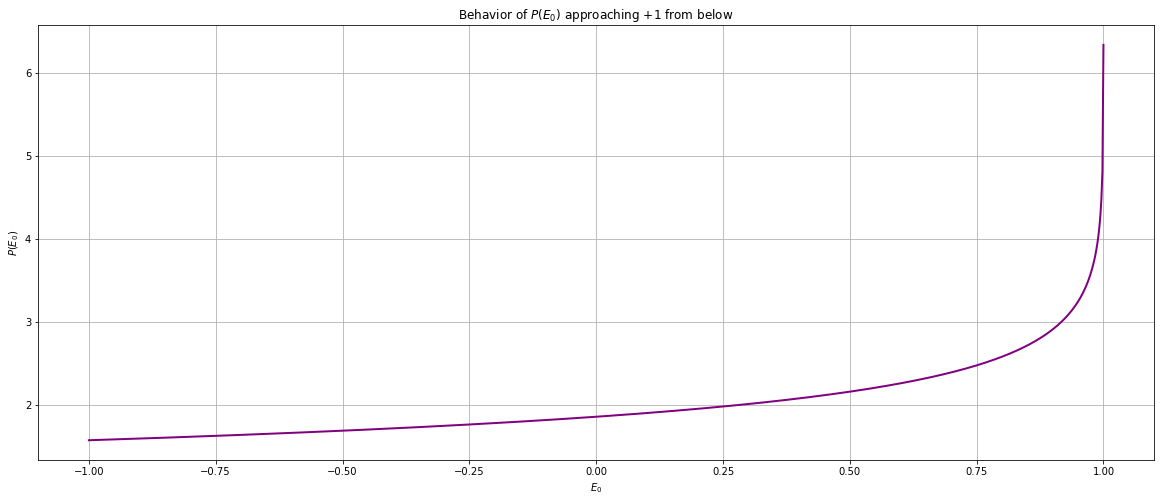

In [4]:
# plotting 2: visualize period integral w.r.t. E0
compute_period_main()

MATLAB solution

```matlab
% Pendulum dynamical system main driver code
clear; clc;
% set initial conditions \theta\in[-\pi,\pi], \omega\in\mathbb{R}
% random initial conditions
theta0 = -pi/2;%unifrnd(-pi,pi);
omega0 = 10;%randn();
% x = (theta,omega)^T
% initial condition of dynamical system
x0 = [theta0;omega0];
% time interval
tstart = 0; tend = 10;
% number of time steps
Nt = 50000; 
tgrid = linspace(tstart,tend,Nt);
dt = tgrid(2)-tgrid(1);
% function handle for ODE45
% make sure output is a column vector
rhs = @(t,x) [x(2,:); -sin(x(1,:))]; 
% numerical ODE solver
[tspan,x_solution] = ode45(rhs,tgrid,x0);
theta_solution = mod(x_solution(:,1)+pi,2*pi)-pi;
omega_solution = x_solution(:,2);
% plotting numerical solutions
figure(1); hold on;
subplot(2,1,1);
plot(tspan,theta_solution,'Color','red','LineWidth',2);
title('Dynamics of \theta');
subplot(2,1,2); 
plot(tspan,omega_solution,'Color','blue','LineWidth',2);
title('Dynamics of \Omega');
% plot energy conservation
figure(2); hold on;
plot(tspan,0.5*omega_solution.^2-cos(theta_solution),'Color','green',...
    'LineWidth',2);
% plot phase space
figure(3); hold on;
plot(theta_solution,omega_solution,'Color','black',...
    'LineWidth',2);
% numerical integral, treated as E0 -> \int_0^\theta_m f(E0,\theta) d\theta
% where f(E0,\theta) = 1/sqrt(2*(E0+cos(\theta)))
P = @(E0) integral(@(theta) 4./sqrt(2*(E0+cos(theta))), ...
    0, acos(-E0));
% generate grid of possible E0 values \in (-1,1)
all_E0 = (-1+0.00001):0.0001:(1-0.00001);
all_E0 = (1+0.00001:0.001:2);
%plot(all_E0, acos(-all_E0))
% evaluate and plot (E0,P(E0))
all_P = zeros([1,length(all_E0)]);
for i = 1:length(all_E0)
    i
    E0 = all_E0(i);
    all_P(i) = P(E0);
end
figure(4);
plot(all_E0,all_P);
```

Comments: To conserve the energy, it is better to use symplectic Euler scheme. Here is the Wiki link: [Symplectic Euler](https://en.wikipedia.org/wiki/Semi-implicit_Euler_method). 
$$\theta_{i+1} = \theta_i + dt*\Omega_i$$
$$\Omega_{i+1} = \Omega_i -dt*\sin(\theta_{i+1})$$

Besides, one can choose higher order schemes like [Verlet scheme](https://en.wikipedia.org/wiki/Verlet_integration).
